# Telco Customer Churn Prediction
**Author:** Kaushik Saha  
**Date:** March 2026  
**Tools:** Python · Pandas · Scikit-learn · XGBoost · KMeans

---

## Project objective
Telecom companies lose significant revenue to customer churn. This project builds a machine learning pipeline to:
1. **Predict** which customers are at risk of churning
2. **Explain** the key drivers of churn
3. **Segment** customers into actionable retention groups

## Dataset
- **Source:** IBM Telco Customer Churn dataset
- **Size:** 7,043 customers, 33 features
- **Target:** `Churn Value` (1 = churned, 0 = retained)
- **Class imbalance:** ~26.5% churn rate — handled via class weighting

## Methodology
| Phase | Techniques |
|---|---|
| Data cleaning | Type fixing, leakage removal, null handling |
| EDA | Distribution plots, correlation heatmap, churn drivers |
| Feature engineering | Binary encoding, one-hot encoding, StandardScaler |
| Modelling | Logistic Regression, Random Forest, XGBoost + GridSearchCV |
| Interpretability | SHAP values, feature importance |
| Segmentation | KMeans clustering (k=3) |

---

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Telco_customer_churn.xlsx to Telco_customer_churn.xlsx


## 1. Setup & imports
Loading all required libraries upfront for visibility and reproducibility.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, recall_score, accuracy_score, f1_score
from sklearn.cluster import KMeans
from xgboost import XGBClassifier
import shap
import warnings
warnings.filterwarnings('ignore')

# Consistent plot styling across all charts

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120

## 2. Data loading & overview

In [3]:
df = pd.read_excel("Telco_customer_churn.xlsx")
df.shape
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [5]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [6]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

## 3. Data cleaning

Key issues identified:
- `Churn Score` dropped — direct leakage of the target variable
- `Zip Code`, `Lat Long`, `Latitude`, `Longitude` dropped — geographic identifiers, not predictive features
- `Total Charges` stored as string — converted to numeric
- `Churn Reason` nulls filled — customers who didn't churn have no reason
"""

In [7]:
# Drop useless / risky columns
df = df.drop(columns=[
    "Count",
    "Zip Code",
    "Latitude",
    "Longitude",
    "Churn Score"
])

In [8]:
df.isnull().sum()

,0
CustomerID,0
Country,0
State,0
City,0
Lat Long,0
Gender,0
Senior Citizen,0
Partner,0
Dependents,0
Tenure Months,0


In [9]:
df["Churn Reason"] = df["Churn Reason"].fillna("No Churn")

In [10]:
# Fix Total Charges
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

In [11]:
df["Total Charges"].isnull().sum()

np.int64(11)

In [12]:
df = df.dropna(subset=["Total Charges"])

In [13]:
df.columns

Index(['CustomerID', 'Country', 'State', 'City', 'Lat Long', 'Gender',
       'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label',
       'Churn Value', 'CLTV', 'Churn Reason'],
      dtype='object')

In [14]:
main_df = df.copy()

In [15]:
model_df = main_df.drop(columns=[
    "CustomerID",
    "Churn Reason",
    "Churn Label"
])

In [16]:
model_df.columns

Index(['Country', 'State', 'City', 'Lat Long', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Value', 'CLTV'],
      dtype='object')

## 4. Exploratory data analysis (EDA)

Goal: understand the shape of churn — who churns, why, and what separates them from loyal customers. Each plot is followed by a key observation.

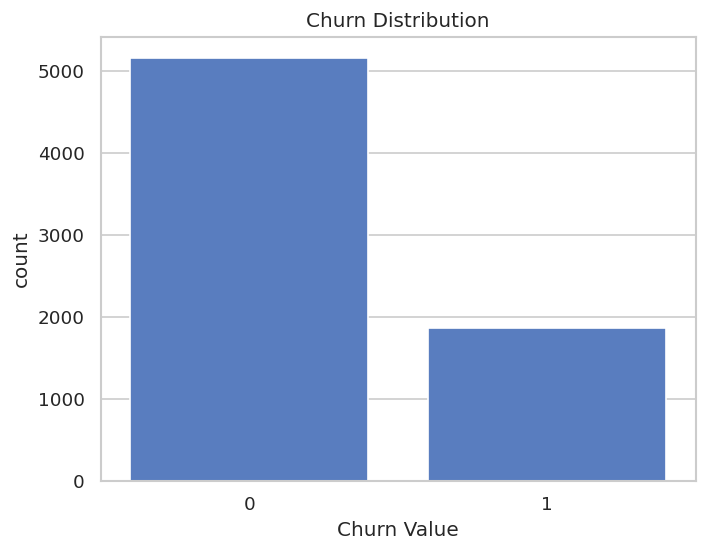

In [17]:
sns.countplot(x="Churn Value", data=main_df)
plt.title("Churn Distribution")
plt.show()

In [18]:
main_df["Churn Value"].value_counts(normalize=True) * 100

,proportion
Churn Value,
0,73.421502
1,26.578498


> **Insight:** The dataset is imbalanced — ~26.5% of customers churned vs 73.5% retained.
> This rules out accuracy as a reliable metric; we will optimise for **recall** to minimise missed churners.

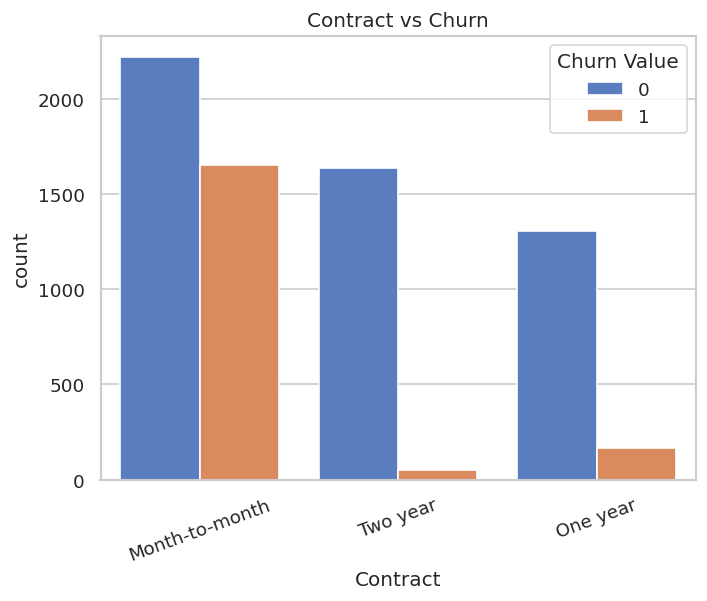

In [19]:
sns.countplot(x="Contract", hue="Churn Value", data=main_df)
plt.title("Contract vs Churn")
plt.xticks(rotation=20)
plt.show()

> **Insight:** Month-to-month contract customers churn at dramatically higher rates than those on
> one or two-year contracts. Contract type is likely the single strongest churn predictor —
> confirmed later by feature importance.

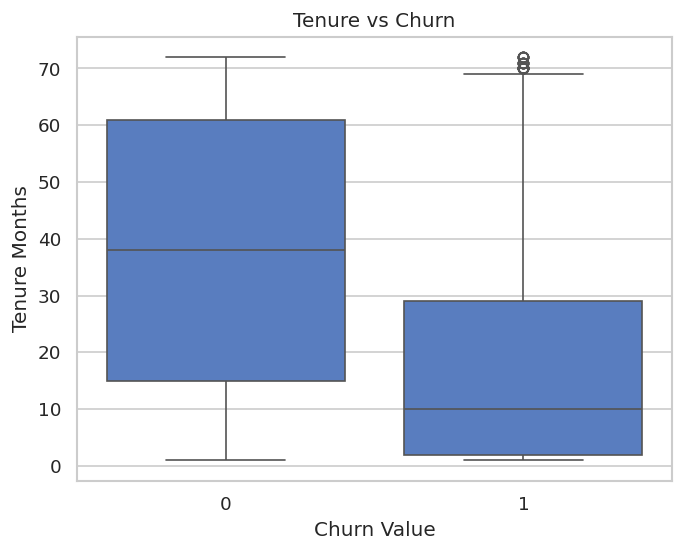

In [20]:
sns.boxplot(x="Churn Value", y="Tenure Months", data=main_df)
plt.title("Tenure vs Churn")
plt.show()

> **Insight:** Churned customers have significantly lower median tenure (~10 months) compared
> to retained customers (~38 months). New customers are the highest risk group — early
> intervention in the first 3–6 months is critical.

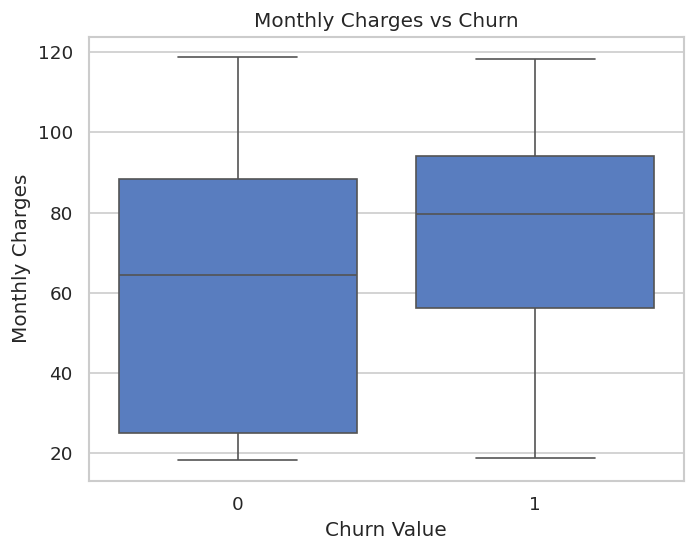

In [21]:
sns.boxplot(x="Churn Value", y="Monthly Charges", data=main_df)
plt.title("Monthly Charges vs Churn")
plt.show()

> **Insight:** Churned customers pay higher monthly charges on average. High-paying customers
> who feel they aren't getting value are the most likely to leave — price sensitivity is a key driver.

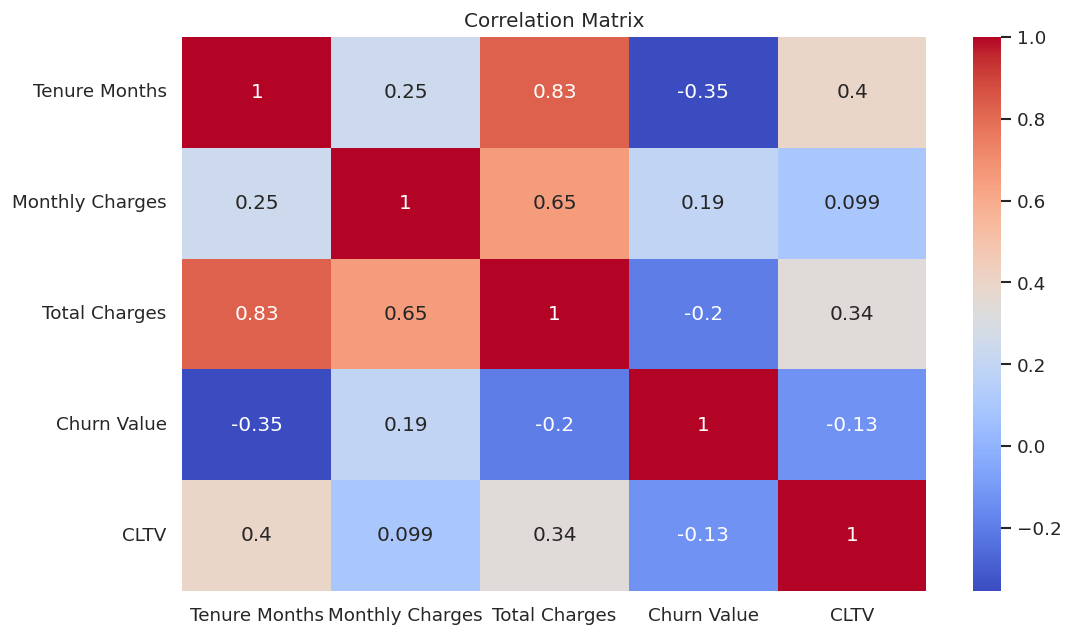

In [22]:
plt.figure(figsize=(10,6))
sns.heatmap(main_df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

> **Insight:** `Tenure Months` and `Total Charges` are strongly correlated (longer customers
> naturally accumulate more charges). `Monthly Charges` shows moderate positive correlation
> with churn. No extreme multicollinearity issues that would break Logistic Regression.

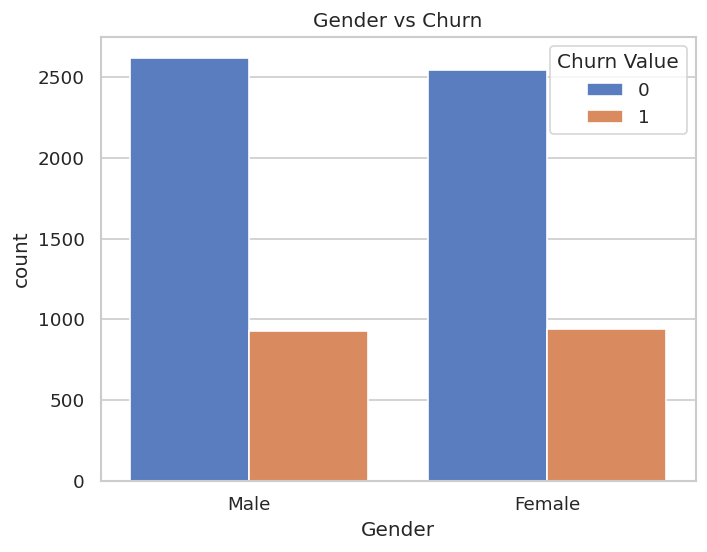

In [23]:
sns.countplot(x="Gender", hue="Churn Value", data=main_df)
plt.title("Gender vs Churn")
plt.show()

> **Insight:** Gender shows virtually no difference in churn rate. It will likely have near-zero
> feature importance in the final model — confirms dropping or deprioritising it.

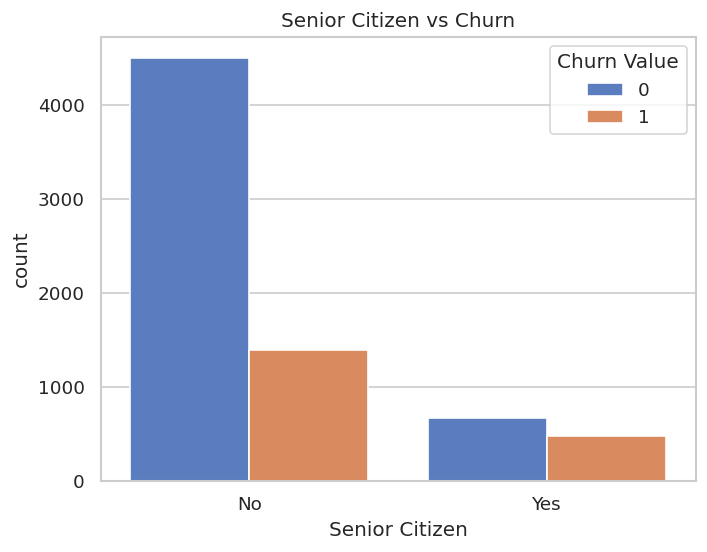

In [24]:
sns.countplot(x="Senior Citizen", hue="Churn Value", data=main_df)
plt.title("Senior Citizen vs Churn")
plt.show()

> **Insight:** Senior citizens churn at a noticeably higher rate. This could reflect
> difficulty navigating digital services or price sensitivity on fixed incomes —
> a segment worth a dedicated retention offer.

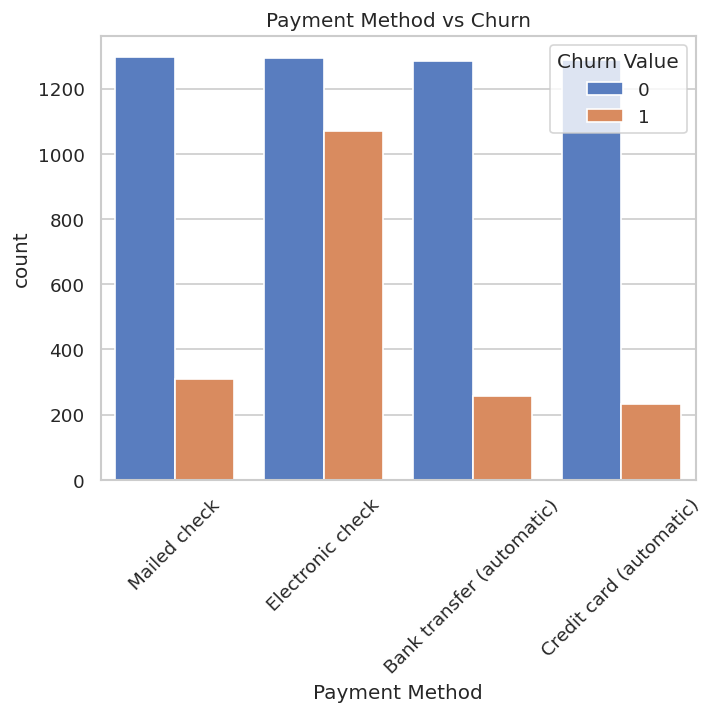

In [25]:
sns.countplot(x="Payment Method", hue="Churn Value", data=main_df)
plt.xticks(rotation=45)
plt.title("Payment Method vs Churn")
plt.show()

> **Insight:** Electronic check users churn far more than customers on automatic payment methods.
> Automatic payment likely signals higher commitment and reduces friction to staying —
> nudging customers toward auto-pay could reduce churn passively.

In [26]:
churn_reasons = main_df[main_df["Churn Value"]==1]["Churn Reason"].value_counts().head(10)
print(churn_reasons)

Churn Reason
Attitude of support person                   192
Competitor offered higher download speeds    189
Competitor offered more data                 162
Don't know                                   154
Competitor made better offer                 140
Attitude of service provider                 135
Competitor had better devices                130
Network reliability                          103
Product dissatisfaction                      102
Price too high                                98
Name: count, dtype: int64


> **Insight:** The top churn reasons are competitor-related (better devices, better offers).
> This signals a pricing and product gap — not a service quality issue. Retention strategy
> should focus on competitive offers, not customer support improvements.

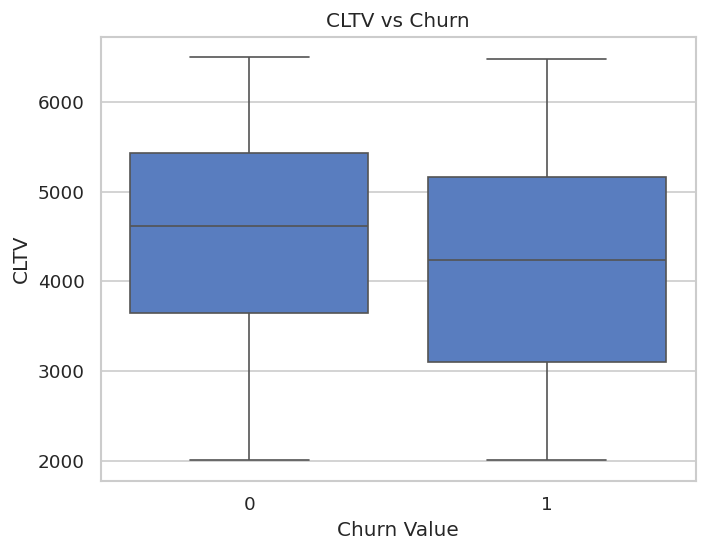

In [27]:
sns.boxplot(x="Churn Value", y="CLTV", data=main_df)
plt.title("CLTV vs Churn")
plt.show()

> **Insight:** Churned customers have lower CLTV scores on average, but the overlap is wide.
> It's clear that CLTV alone isn't a reliable churn predictor — it needs to be combined with other features.

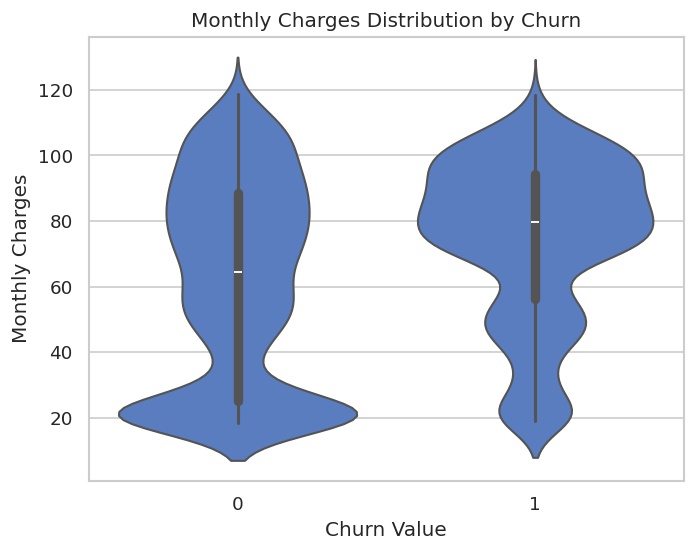

In [28]:
sns.violinplot(x="Churn Value", y="Monthly Charges", data=main_df)
plt.title("Monthly Charges Distribution by Churn")
plt.show()

> **Insight:** The violin plot confirms a bimodal distribution among retained customers —
> a large low-charge group and a smaller high-charge group who stay despite high costs
> (likely on long-term contracts). Churned customers cluster tightly around higher charges.

## 5. Feature engineering

Three encoding steps:
- **Binary columns** (Yes/No) → 0/1 integer mapping
- **Gender** → Male = 1, Female = 0
- **Multi-category columns** → one-hot encoding with `drop_first=True` to avoid multicollinearity
- **Numeric columns** → StandardScaler (mean=0, std=1) required by Logistic Regression; improves convergence for all models

In [29]:
# Drop zero-value columns still in model_df
model_df = model_df.drop(columns=['Country', 'State', 'City', 'Lat Long'])

# Verify
print("Shape:", model_df.shape)
print("NaN count:", model_df.isnull().sum().sum())
print("\nColumns:", model_df.columns.tolist())

Shape: (7032, 21)
NaN count: 0

Columns: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value', 'CLTV']


In [30]:
# Binary columns: Yes/No → 1/0
binary_cols = ['Partner', 'Dependents', 'Phone Service', 'Paperless Billing']

for col in binary_cols:
    model_df[col] = model_df[col].map({'Yes': 1, 'No': 0})

# Gender: Male → 1, Female → 0
model_df['Gender'] = model_df['Gender'].map({'Male': 1, 'Female': 0})

# Senior Citizen: Yes → 1, No → 0
model_df['Senior Citizen'] = model_df['Senior Citizen'].map({'Yes': 1, 'No': 0})

# Verify
print(model_df[['Gender', 'Senior Citizen', 'Partner', 'Dependents',
                 'Phone Service', 'Paperless Billing']].head())
print("\nDtypes:\n", model_df.dtypes)

   Gender  Senior Citizen  Partner  Dependents  Phone Service  \
0       1               0        0           0              1   
1       0               0        0           1              1   
2       0               0        0           1              1   
3       0               0        1           1              1   
4       1               0        0           1              1   

   Paperless Billing  
0                  1  
1                  1  
2                  1  
3                  1  
4                  1  

Dtypes:
 Gender                 int64
Senior Citizen         int64
Partner                int64
Dependents             int64
Tenure Months          int64
Phone Service          int64
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing      int

In [31]:
# Multi-category columns → One-Hot Encoding
multi_cols = ['Multiple Lines', 'Internet Service', 'Online Security',
              'Online Backup', 'Device Protection', 'Tech Support',
              'Streaming TV', 'Streaming Movies', 'Contract', 'Payment Method']

model_df = pd.get_dummies(model_df, columns=multi_cols, drop_first=True)

# Verify
print("Shape:", model_df.shape)
print("\nColumns:", model_df.columns.tolist())

Shape: (7032, 32)

Columns: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Paperless Billing', 'Monthly Charges', 'Total Charges', 'Churn Value', 'CLTV', 'Multiple Lines_No phone service', 'Multiple Lines_Yes', 'Internet Service_Fiber optic', 'Internet Service_No', 'Online Security_No internet service', 'Online Security_Yes', 'Online Backup_No internet service', 'Online Backup_Yes', 'Device Protection_No internet service', 'Device Protection_Yes', 'Tech Support_No internet service', 'Tech Support_Yes', 'Streaming TV_No internet service', 'Streaming TV_Yes', 'Streaming Movies_No internet service', 'Streaming Movies_Yes', 'Contract_One year', 'Contract_Two year', 'Payment Method_Credit card (automatic)', 'Payment Method_Electronic check', 'Payment Method_Mailed check']


In [32]:
from sklearn.preprocessing import StandardScaler

# Numeric columns to scale
num_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']

scaler = StandardScaler()
model_df[num_cols] = scaler.fit_transform(model_df[num_cols])

# Verify
print(model_df[num_cols].describe().round(2))

       Tenure Months  Monthly Charges  Total Charges     CLTV
count        7032.00          7032.00        7032.00  7032.00
mean           -0.00             0.00           0.00     0.00
std             1.00             1.00           1.00     1.00
min            -1.28            -1.55          -1.00    -2.03
25%            -0.95            -0.97          -0.83    -0.79
50%            -0.14             0.18          -0.39     0.11
75%             0.92             0.83           0.67     0.83
max             1.61             1.79           2.82     1.77


In [33]:
from sklearn.model_selection import train_test_split


X = model_df.drop(columns=['Churn Value'])
y = model_df['Churn Value']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Verify
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("\nTrain churn rate:", y_train.mean().round(3))
print("Test churn rate:", y_test.mean().round(3))

X_train shape: (5625, 31)
X_test shape: (1407, 31)

Train churn rate: 0.266
Test churn rate: 0.266


## 6. Modelling

Three classifiers trained and evaluated:
| Model | Why included |
|---|---|
| Logistic Regression | Interpretable baseline |
| Random Forest | Handles non-linearity, robust to outliers |
| XGBoost | High performance on tabular data |

**Optimisation metric: Recall** — missing a churner (false negative) is more costly than a false alarm (false positive).

Logistic Regression
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1033
           1       0.64      0.61      0.63       374

    accuracy                           0.81      1407
   macro avg       0.75      0.74      0.75      1407
weighted avg       0.80      0.81      0.80      1407



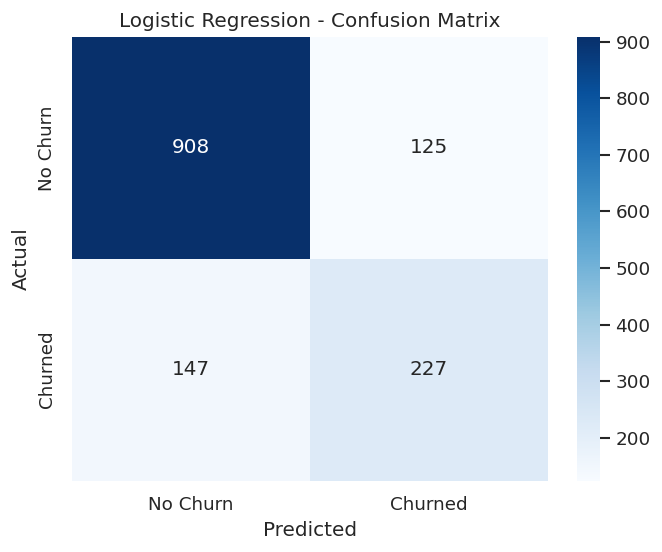

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix


lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

# Predict
lr_pred = lr.predict(X_test)

# Results
print("Logistic Regression")
print(classification_report(y_test, lr_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churned'],
            yticklabels=['No Churn', 'Churned'])
plt.title('Logistic Regression - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [35]:
# Parameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'class_weight': ['balanced', None]
}

lr = LogisticRegression(max_iter=1000, random_state=42)

grid_search = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    scoring='recall',      # priority recall
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Params:", grid_search.best_params_)
print("Best CV Recall:", grid_search.best_score_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best Params: {'C': 10, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
Best CV Recall: 0.8147157190635452



Logistic Regression (Tuned)
              precision    recall  f1-score   support

           0       0.90      0.71      0.79      1033
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.75      1407



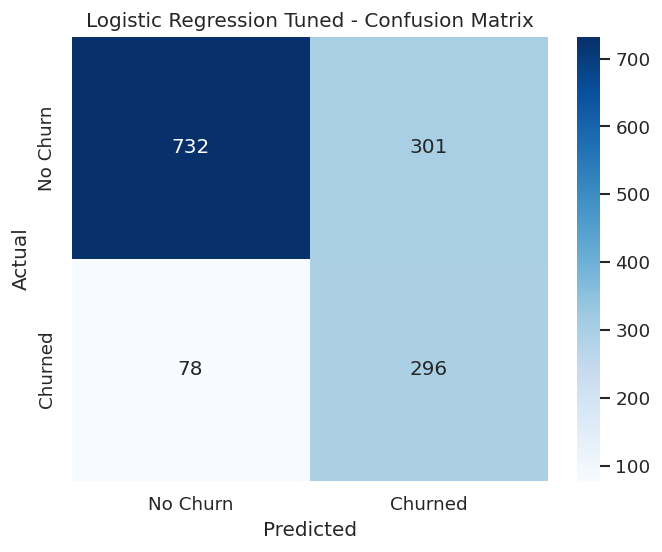

In [36]:
best_lr = grid_search.best_estimator_
lr_pred = best_lr.predict(X_test)

print("\nLogistic Regression (Tuned)")
print(classification_report(y_test, lr_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churned'],
            yticklabels=['No Churn', 'Churned'])
plt.title('Logistic Regression Tuned - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

Random Forest
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



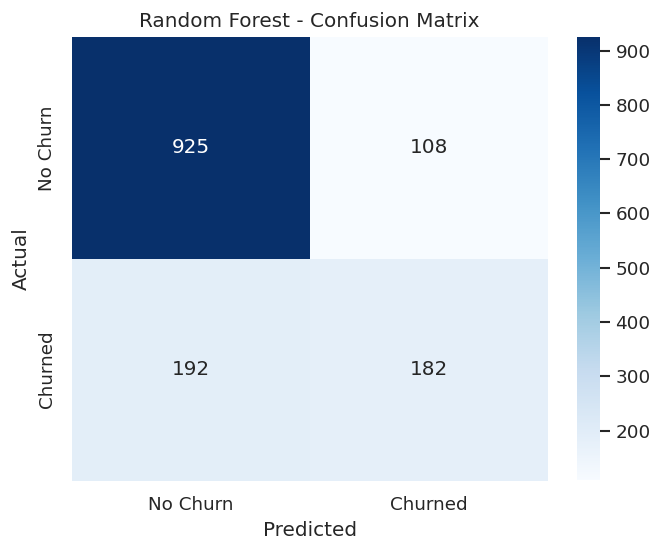

In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

# Predict
rf_pred = rf.predict(X_test)

# Results
print("Random Forest")
print(classification_report(y_test, rf_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churned'],
            yticklabels=['No Churn', 'Churned'])
plt.title('Random Forest - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [38]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [200, 250],
    'max_depth': [5, 6, 7],
    'min_samples_leaf': [5,7]
}


grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best Recall:", grid.best_score_.round(3))

Best parameters: {'max_depth': 5, 'min_samples_leaf': 5, 'n_estimators': 200}
Best Recall: 0.825


Final Random Forest
              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.50      0.81      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.74      1407



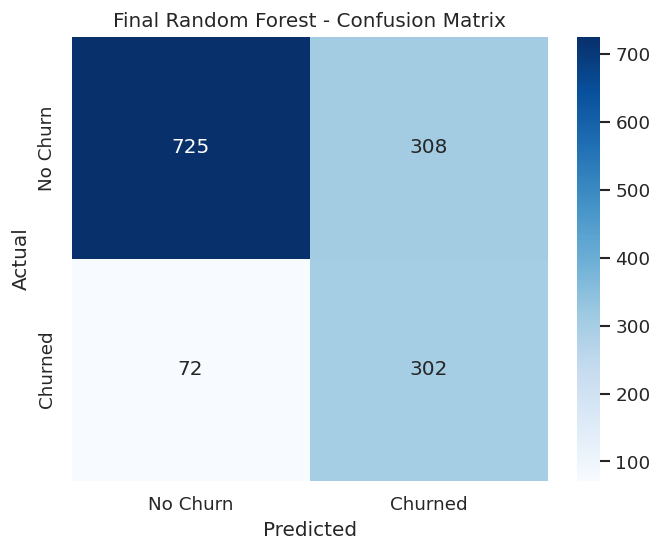

In [39]:
final_rf = grid.best_estimator_
final_pred = final_rf.predict(X_test)

# Results
print("Final Random Forest")
print(classification_report(y_test, final_pred))


# Confusion Matrix
cm = confusion_matrix(y_test, final_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churned'],
            yticklabels=['No Churn', 'Churned'])
plt.title('Final Random Forest - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [40]:
# Class ratio
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
print(neg, pos, neg/pos)

4130 1495 2.762541806020067


XGBoost
              precision    recall  f1-score   support

           0       0.87      0.80      0.83      1033
           1       0.55      0.67      0.61       374

    accuracy                           0.77      1407
   macro avg       0.71      0.74      0.72      1407
weighted avg       0.79      0.77      0.77      1407



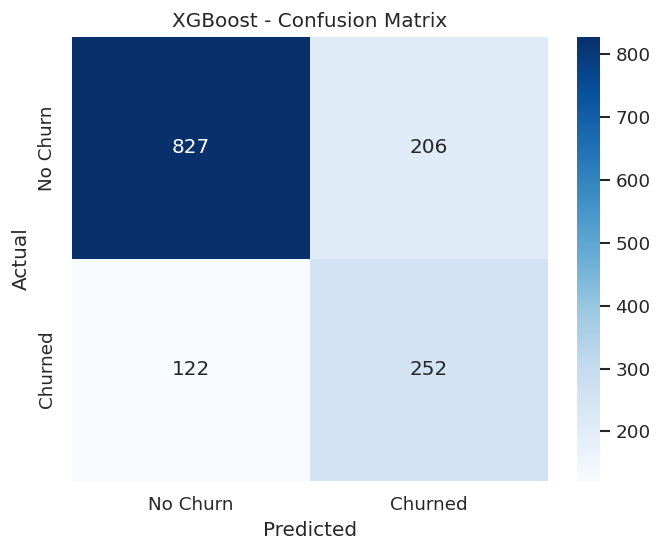

In [41]:
spw = 4130 / 1495

xgb = XGBClassifier(
    scale_pos_weight= spw,
    random_state=42
    )
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

print("XGBoost")
print(classification_report(y_test, xgb_pred))

cm = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churned'],
            yticklabels=['No Churn', 'Churned'])
plt.title('XGBoost - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [42]:
from sklearn.model_selection import GridSearchCV


spw = 4130 / 1495
param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [2, 3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'scale_pos_weight': [spw]
}

grid_xgb = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)
grid_xgb.fit(X_train, y_train)

print("Best params:", grid_xgb.best_params_)
print("Best Recall:", grid_xgb.best_score_.round(3))

Best params: {'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 50, 'scale_pos_weight': 2.762541806020067}
Best Recall: 0.861


Final XGBoost
              precision    recall  f1-score   support

           0       0.92      0.59      0.72      1033
           1       0.43      0.86      0.58       374

    accuracy                           0.66      1407
   macro avg       0.68      0.73      0.65      1407
weighted avg       0.79      0.66      0.68      1407



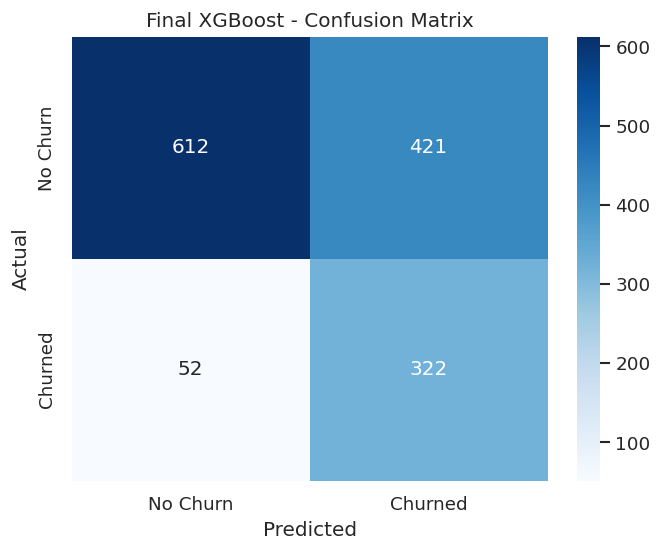

In [43]:
final_xgb = grid_xgb.best_estimator_
final_xgb_pred = final_xgb.predict(X_test)

print("Final XGBoost")
print(classification_report(y_test, final_xgb_pred))

cm = confusion_matrix(y_test, final_xgb_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churned'],
            yticklabels=['No Churn', 'Churned'])
plt.title('Final XGBoost - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [44]:
param_grid = {
    'n_estimators': [200, 225, 250],
    'max_depth': [3, 4],
    'learning_rate': [0.01, 0.1, 1],
    'scale_pos_weight': [spw]
}

grid_xgb_f1 = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_xgb_f1.fit(X_train, y_train)

best_xgb_f1 = grid_xgb_f1.best_estimator_
y_pred_f1 = best_xgb_f1.predict(X_test)

print("Best params:", grid_xgb_f1.best_params_)
print("\nXGBoost (F1 Tuned)")
print(classification_report(y_test, y_pred_f1))

Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'scale_pos_weight': 2.762541806020067}

XGBoost (F1 Tuned)
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1033
           1       0.50      0.80      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.74      0.75      1407



In [46]:
from sklearn.metrics import precision_recall_curve

y_proba = best_xgb_f1.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

for thresh in [0.3, 0.35, 0.4, 0.45, 0.5, 0.6]:
    preds = (y_proba >= thresh).astype(int)
    acc = accuracy_score(y_test, preds)
    rec = recall_score(y_test, preds)
    print(f"Threshold {thresh:.2f} → Accuracy: {acc:.3f} | Recall: {rec:.3f}")

Threshold 0.30 → Accuracy: 0.667 | Recall: 0.888
Threshold 0.35 → Accuracy: 0.693 | Recall: 0.861
Threshold 0.40 → Accuracy: 0.706 | Recall: 0.850
Threshold 0.45 → Accuracy: 0.717 | Recall: 0.826
Threshold 0.50 → Accuracy: 0.737 | Recall: 0.797
Threshold 0.60 → Accuracy: 0.769 | Recall: 0.727


In [47]:
from sklearn.metrics import precision_score

for thresh in [0.45, 0.50]:
    preds = (y_proba >= thresh).astype(int)
    acc = accuracy_score(y_test, preds)
    rec = recall_score(y_test, preds)
    pre = precision_score(y_test, preds)
    f1  = f1_score(y_test, preds)
    print(f"Threshold {thresh} → Accuracy: {acc:.3f} | Recall: {rec:.3f} | Precision: {pre:.3f} | F1: {f1:.3f}")

Threshold 0.45 → Accuracy: 0.717 | Recall: 0.826 | Precision: 0.481 | F1: 0.608
Threshold 0.5 → Accuracy: 0.737 | Recall: 0.797 | Precision: 0.503 | F1: 0.617


In [48]:
# Business Threshold Analysis
print(f"{'Threshold':>10} {'Accuracy':>10} {'Recall':>10} {'Use Case':>30}")
print("-" * 65)
scenarios = {
    0.35: "Minimize missed churners",
    0.50: "Balanced (recommended)",
    0.60: "Minimize false alarms"
}
for thresh, use_case in scenarios.items():
    preds = (y_proba >= thresh).astype(int)
    acc = accuracy_score(y_test, preds)
    rec = recall_score(y_test, preds)
    print(f"{thresh:>10.2f} {acc:>10.3f} {rec:>10.3f} {use_case:>30}")

 Threshold   Accuracy     Recall                       Use Case
-----------------------------------------------------------------
      0.35      0.693      0.861       Minimize missed churners
      0.50      0.737      0.797         Balanced (recommended)
      0.60      0.769      0.727          Minimize false alarms


> **Business note:** Threshold selection should ideally be driven by the
> relative cost of a false negative (missed churner) vs a false positive
> (unnecessary retention offer). Without exact cost figures, 0.50 was chosen
> as a balanced default — but a lower threshold (e.g. 0.35) may be preferable
> if retention offer costs are low.

In [49]:
results = {
    'Model': ['Logistic Regression', 'Random Forest',
              'XGBoost (Old)', 'XGBoost (F1 Tuned)'],
    'Accuracy': [0.731, 0.730, 0.664, 0.737],
    'Recall':   [0.791, 0.807, 0.861, 0.797],
    'Precision':[0.496, 0.495, 0.433, 0.503],
    'F1':       [0.610, 0.614, 0.577, 0.617]
}

df_results = pd.DataFrame(results)
df_results = df_results.sort_values('F1', ascending=False).reset_index(drop=True)
display(df_results)

,Model,Accuracy,Recall,Precision,F1
0,XGBoost (F1 Tuned),0.737,0.797,0.503,0.617
1,Random Forest,0.730,0.807,0.495,0.614
2,Logistic Regression,0.731,0.791,0.496,0.610
3,XGBoost (Old),0.664,0.861,0.433,0.577


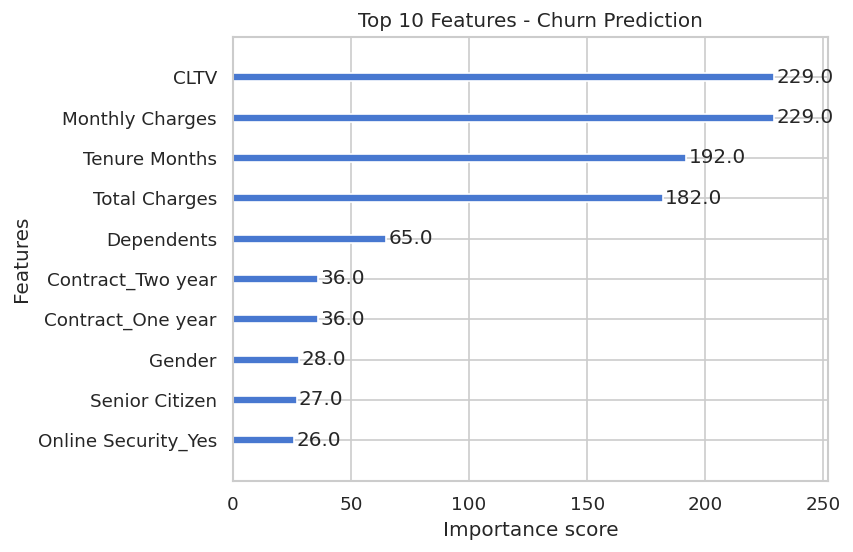

In [50]:
from xgboost import plot_importance
plot_importance(best_xgb_f1, max_num_features=10)
plt.title('Top 10 Features - Churn Prediction')
plt.show()

## 7. Model interpretability — SHAP values

XGBoost gives us strong predictions, but a real business needs to know *why* a customer
is predicted to churn — not just *that* they will.

SHAP (SHapley Additive exPlanations) explains each prediction by measuring how much
each feature pushed the result toward or away from churn.

- **Global view:** which features drive churn across all customers?
- **Local view:** why did the model flag *this specific customer* as high risk?

In [51]:
# SHAP works by observing how predictions change as feature values change
# TreeExplainer is optimised specifically for tree-based models like XGBoost

explainer = shap.TreeExplainer(best_xgb_f1)

# Calculate SHAP values for every customer in the test set

shap_values = explainer.shap_values(X_test)

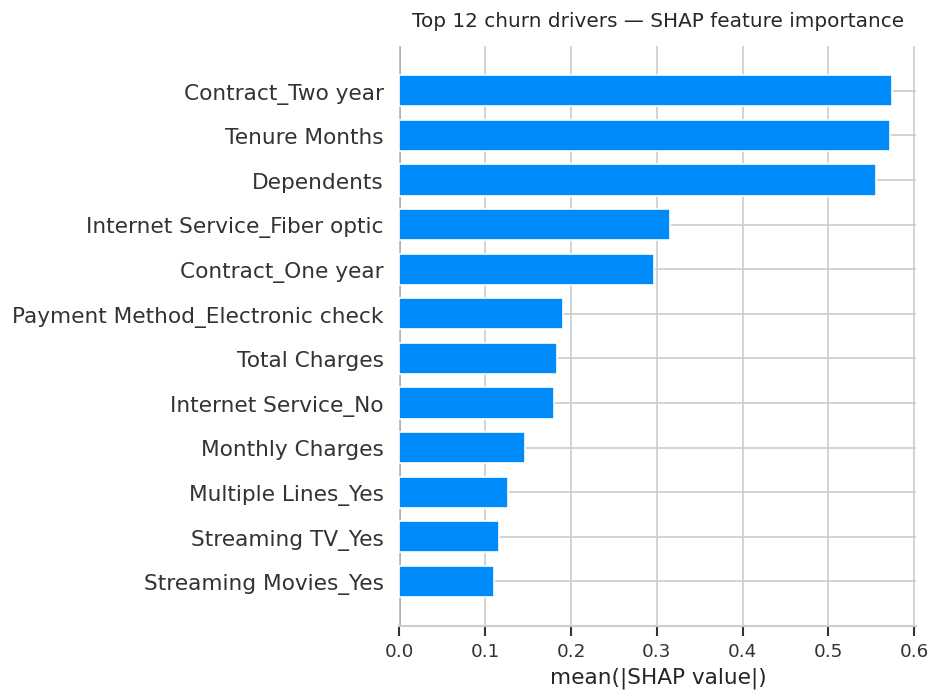

In [52]:
# Global explanation:
# Shows which features have the biggest overall impact on churn prediction
# Each dot is one customer — red means high feature value, blue means low
# Position on x-axis shows whether it pushed prediction toward churn (right) or away (left)

plt.close('all')

# Tell SHAP not to render — we'll control the output ourselves

shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=12, show=False)

# Now grab the figure SHAP created and style it ourselves

fig = plt.gcf()
ax = plt.gca()
ax.set_title("Top 12 churn drivers — SHAP feature importance", pad=12)
ax.set_xlabel("mean(|SHAP value|)")
fig.set_size_inches(8, 6)
plt.tight_layout()
plt.show()
plt.close('all')

Customer index    : 3
Actual label      : Churned
Model prediction  : No Churn
Churn probability : 31.18%


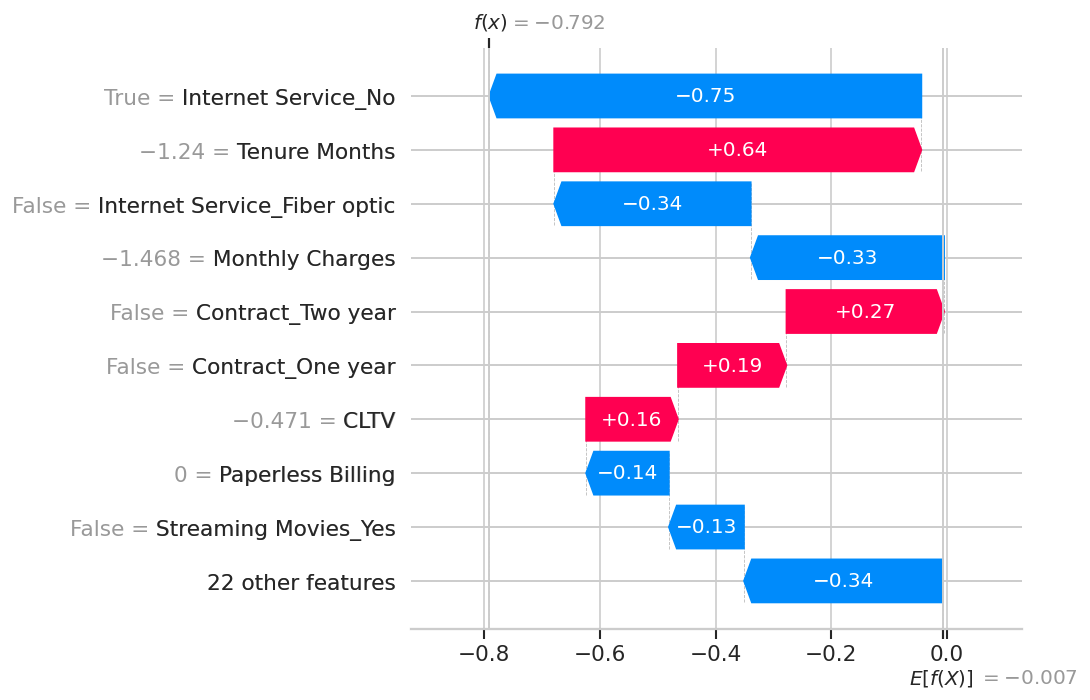

In [53]:
plt.close('all')

# Find the first customer in the test set who actually churned
churned_indices = np.where(y_test.values == 1)[0]
customer_idx = churned_indices[0]

print(f"Customer index    : {customer_idx}")
print(f"Actual label      : Churned")
print(f"Model prediction  : {'Churned' if y_pred_f1[customer_idx] == 1 else 'No Churn'}")
print(f"Churn probability : {best_xgb_f1.predict_proba(X_test)[customer_idx][1]:.2%}")

# Build the SHAP Explanation object for this one customer
explanation = shap.Explanation(
    values=shap_values[customer_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[customer_idx].values,
    feature_names=X_test.columns.tolist()
)

# Waterfall plot — shows exactly how each feature pushed this customer's score
shap.plots.waterfall(explanation, show=False)
fig = plt.gcf()
fig.set_size_inches(9, 6)
plt.tight_layout()
plt.show()
plt.close('all')

> **Insight:** Churned customers pay higher monthly charges on average.
> However, SHAP analysis later shows that price alone is not the primary
> driver — contract type and tenure rank significantly higher. High charges
> may amplify churn risk, but they are rarely the root cause on their own.

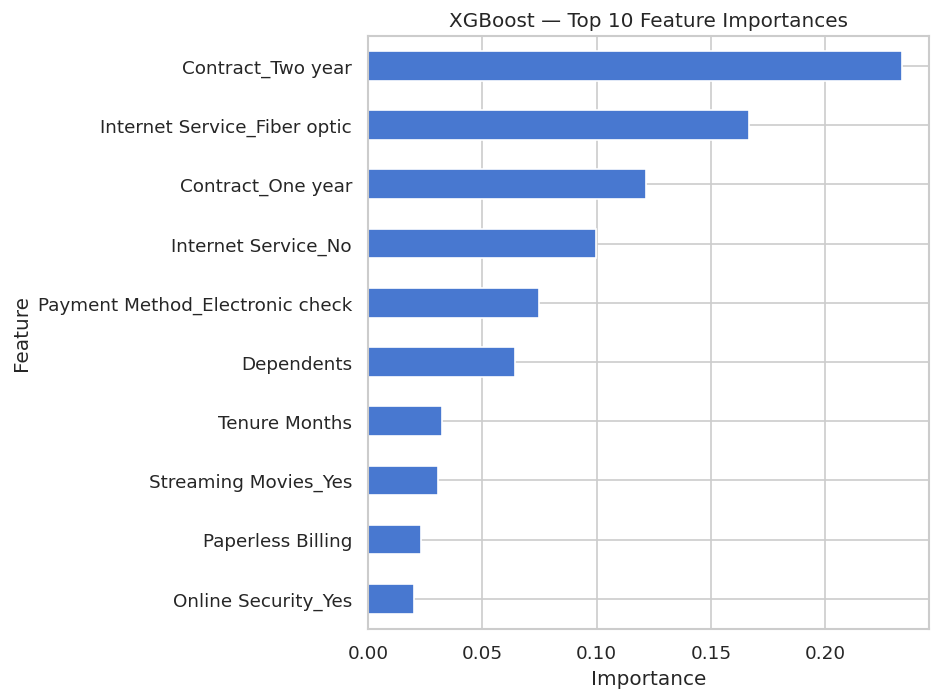

In [54]:
feat_imp_df = pd.DataFrame({
    'Feature': X_train.columns.tolist(),
    'Importance': best_xgb_f1.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

feat_imp_df.plot(kind='barh', x='Feature', y='Importance', figsize=(8,6), legend=False)
plt.title('XGBoost — Top 10 Feature Importances')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

feat_imp_df.to_csv('feature_importance.csv', index=False)

## 8. Customer segmentation (KMeans) using Elbow method

Unsupervised clustering on financial + tenure features to identify distinct customer groups for targeted retention strategies.

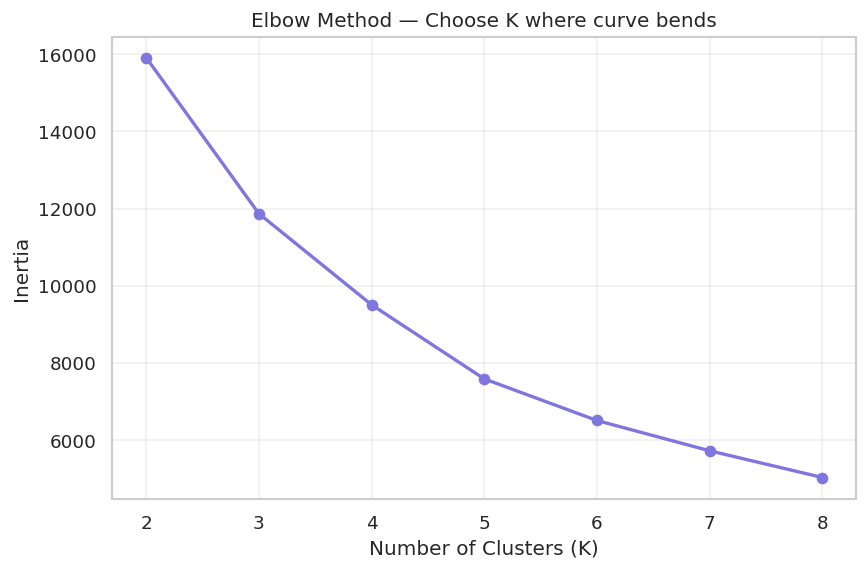

In [55]:
from sklearn.cluster import KMeans

cluster_features = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']
X_cluster = model_df[cluster_features].copy()

# Elbow Method
inertias = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker='o', color='#7F77DD', linewidth=2)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Choose K where curve bends')
plt.xticks(K_range)
plt.grid(alpha=0.3)
plt.show()

In [56]:

km = KMeans(n_clusters=3, random_state=42, n_init=10)
model_df['Cluster'] = km.fit_predict(X_cluster)

cluster_summary = model_df.groupby('Cluster')[cluster_features + ['Churn Value']].mean().round(2)

print(cluster_summary)

         Tenure Months  Monthly Charges  Total Charges  CLTV  Churn Value
Cluster                                                                  
0                -0.25            -0.68          -0.58  0.58         0.24
1                -0.66            -0.04          -0.55 -1.10         0.38
2                 1.09             0.86           1.35  0.59         0.15


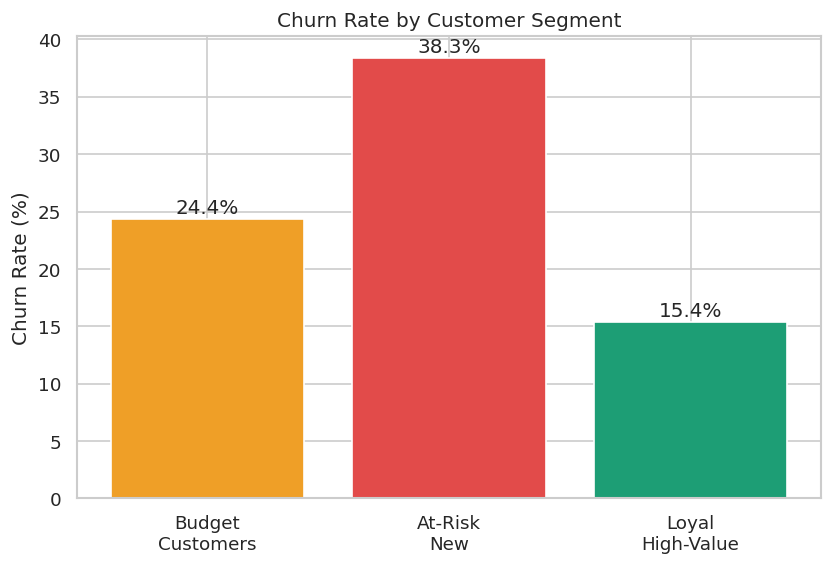

In [57]:
# cluster_map
cluster_map = {
    0: 'Budget\nCustomers',
    1: 'At-Risk\nNew',
    2: 'Loyal\nHigh-Value'
}

cluster_churn = model_df.groupby('Cluster')['Churn Value'].mean() * 100
cluster_labels = [cluster_map[i] for i in sorted(cluster_churn.index)]
colors = {
    'Budget\nCustomers': '#EF9F27',
    'At-Risk\nNew': '#E24B4A',
    'Loyal\nHigh-Value': '#1D9E75'
}
bar_colors = [colors[label] for label in cluster_labels]

plt.figure(figsize=(8, 5))
bars = plt.bar(cluster_labels, cluster_churn, color=bar_colors)

for bar, val in zip(bars, cluster_churn):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontsize=12)

plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Customer Segment')
plt.show()

## 9. Retention strategy

In [61]:

print("RETENTION STRATEGY BY CUSTOMER SEGMENT")


print("""
🔴 Cluster 1 — At-Risk New Customers (Churn 38%)
─────────────────────────────────────────────────
- Launch discount and coupons for 11-25 tenure range customers to attract low tenure customers
- Offer cashback on monthly subscription
- Offer special discount in first 3 months
- Convert month-to-month to yearly contract
- Send personal call/SMS in first month
- Assign dedicated support representative

🟡 Cluster 0 — Budget Customers (Churn 24%)
─────────────────────────────────────────────────
- Offer affordable plan upgrades
- Introduce loyalty points & reward program
- Provide free add-ons (extra data, free service)
- Send personalized retention offers

🟢 Cluster 2 — Loyal High-Value (Churn 15%)
─────────────────────────────────────────────────
- Provide VIP treatment & priority support
- Give early access to new features
- Send annual loyalty rewards & gifts
- Trigger immediate retention call if churn signal detected
""")

RETENTION STRATEGY BY CUSTOMER SEGMENT

🔴 Cluster 1 — At-Risk New Customers (Churn 38%)
─────────────────────────────────────────────────
- Launch discount and coupons for 11-25 tenure range customers to attract low tenure customers
- Offer cashback on monthly subscription
- Offer special discount in first 3 months
- Convert month-to-month to yearly contract
- Send personal call/SMS in first month
- Assign dedicated support representative

🟡 Cluster 0 — Budget Customers (Churn 24%)
─────────────────────────────────────────────────
- Offer affordable plan upgrades
- Introduce loyalty points & reward program
- Provide free add-ons (extra data, free service)
- Send personalized retention offers

🟢 Cluster 2 — Loyal High-Value (Churn 15%)
─────────────────────────────────────────────────
- Provide VIP treatment & priority support
- Give early access to new features
- Send annual loyalty rewards & gifts
- Trigger immediate retention call if churn signal detected



## 10. Conclusion & business recommendations

### Model results summary

| Model | Accuracy | Recall | Precision | F1 Score |
|---|---|---|---|---|
| Logistic Regression | 0.731 | 0.791 | 0.496 | 0.610 |
| Random Forest | 0.730 | 0.807 | 0.495 | 0.614 |
| XGBoost (Initial) | 0.664 | 0.861 | 0.433 | 0.577 |
| **XGBoost (F1 Tuned)** | **0.737** | **0.797** | **0.503** | **0.617** |

**Winner: XGBoost (F1 Tuned)** — chosen for the best overall balance across all
metrics. With a decision threshold of 0.50, it achieves 79.7% recall while
maintaining the highest accuracy (73.7%) and precision (50.3%) among all models.
In a retention context, this balance ensures strong churner detection without
overwhelming the retention team with false alarms.

---

### Key findings

- **Contract type is the #1 churn driver** — month-to-month customers churn at
  dramatically higher rates than those on annual or two-year contracts
- **New customers are the highest risk** — short tenure is the second strongest
  SHAP predictor, meaning early-stage customers need the most attention
- **Fiber optic users churn more** — Internet Service_Fiber optic ranks 4th in
  SHAP importance, suggesting pricing or service quality issues in this segment
- **Electronic check users churn more** — customers not on automatic payment
  methods correlate strongly with higher churn risk
- **CLTV alone is not decisive** — despite ranking highly in tree-based feature
  importance, SHAP analysis shows contract type and tenure have far greater
  real impact on churn prediction

---

### Customer segments

| Segment | Churn Rate | Priority |
|---|---|---|
| At-Risk New customers | 38% | Critical |
| Budget customers | 24% | Medium |
| Loyal High-Value | Low | Maintain |

---

### Retention recommendations

1. **Convert month-to-month customers to annual contracts early** — offer a
   first-month discount or free service upgrade as an incentive
2. **Launch a 90-day onboarding program** for all new customers — assign a
   dedicated support contact in the first month
3. **Nudge electronic check users toward auto-pay** — reduces friction to staying
   and correlates with lower churn
4. **Protect Loyal High-Value customers proactively** — loyalty rewards and
   premium support before they show any churn signals

---

### Limitations & future work

- SHAP local explanations could be productionised into a per-customer risk report
- A/B testing the retention strategies above would validate their real-world impact
- Model could be retrained monthly as new customer data arrives

In [59]:

main_df['Cluster'] = model_df['Cluster']


cluster_map = {
    0: 'Budget Customers',
    1: 'At-Risk New',
    2: 'Loyal High-Value'
}
main_df['Segment'] = main_df['Cluster'].map(cluster_map)


print("Shape:", main_df.shape)
print("\nSegment counts:")
print(main_df['Segment'].value_counts())

Shape: (7032, 30)

Segment counts:
Segment
Budget Customers    2511
At-Risk New         2446
Loyal High-Value    2075
Name: count, dtype: int64


In [60]:
main_df.head()

,CustomerID,Country,State,City,Lat Long,Gender,Senior Citizen,Partner,Dependents,Tenure Months,...,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,CLTV,Churn Reason,Cluster,Segment
0,3668-QPYBK,United States,California,Los Angeles,"33.964131, -118.272783",Male,No,No,No,2,...,Yes,Mailed check,53.85,108.15,Yes,1,3239,Competitor made better offer,1,At-Risk New
1,9237-HQITU,United States,California,Los Angeles,"34.059281, -118.30742",Female,No,No,Yes,2,...,Yes,Electronic check,70.70,151.65,Yes,1,2701,Moved,1,At-Risk New
2,9305-CDSKC,United States,California,Los Angeles,"34.048013, -118.293953",Female,No,No,Yes,8,...,Yes,Electronic check,99.65,820.50,Yes,1,5372,Moved,0,Budget Customers
3,7892-POOKP,United States,California,Los Angeles,"34.062125, -118.315709",Female,No,Yes,Yes,28,...,Yes,Electronic check,104.80,3046.05,Yes,1,5003,Moved,2,Loyal High-Value
4,0280-XJGEX,United States,California,Los Angeles,"34.039224, -118.266293",Male,No,No,Yes,49,...,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,5340,Competitor had better devices,2,Loyal High-Value
